# Battle Outcome Model — Winner Prediction (`wina`)

This notebook trains a classification model to predict `wina` (1 = attacker wins, 0 = defender wins).
Only pre-battle features are used, selected for compatibility with the Peninsular War RL simulation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (make_scorer, f1_score, classification_report,confusion_matrix)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from tqdm import tqdm

## 1. Load Data & Select Features

In [2]:
df = pd.read_excel('History_Battles.xlsx')

# Fields selected for the Peninsular War simulation
# Features: pre-battle information only
# Targets: wina (classification), casualties (regression — separate notebook)
keep_cols = [
    # Pre-battle features
    'post1',          # Defensive posture adopted (HD, PD, FD, DL, WD)
    'surpa',          # Attacker surprise advantage
    'morala',         # Morale advantage
    'logsa',          # Logistics advantage
    'momnta',         # Momentum advantage
    'techa',          # Technology advantage (will be hardcoded per faction in simulation)
    'inita',          # Initiative advantage (highest correlation with wina: 0.37)
    'attacker_str',   # Attacker army size
    'attacker_cav',   # Attacker cavalry
    'attacker_arty',  # Attacker artillery
    'defender_str',   # Defender army size
    'defender_cav',   # Defender cavalry
    'defender_arty',  # Defender artillery
    'terra1',         # Primary terrain type
    'terra2',         # Secondary terrain type
    'attacker_pri1',  # Attacker tactical plan (FF, PP, EE, etc.)
    'defender_pri1',  # Defender tactical plan
    'att_comm_quality',  # Attacker commander overall quality (win rate across all battles)
    'def_comm_quality',  # Defender commander overall quality (win rate across all battles)
    # Targets
    'wina',
    'attacker_cas',
    'defender_cas',
    'attacker_carty',
    'defender_carty'
]

df = df[keep_cols]
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (660, 24)


,post1,surpa,morala,logsa,momnta,techa,inita,attacker_str,attacker_cav,attacker_arty,...,terra2,attacker_pri1,defender_pri1,att_comm_quality,def_comm_quality,wina,attacker_cas,defender_cas,attacker_carty,defender_carty
0,HD,0.0,0.0,0.0,1.0,0.0,1.0,11500.0,1500.0,8.0,...,B,FF,DO,0.0,1.0000,0,4000.0,1000.0,8.0,0.0
1,HD,0.0,0.0,0.0,1.0,0.0,1.0,40000.0,7500.0,12.0,...,M,FF,DO,1.0,0.0000,1,400.0,5000.0,0.0,10.0
2,HD,0.0,0.0,0.0,NaN,0.0,0.0,20000.0,4000.0,8.0,...,M,FF,DD,0.5,0.0000,1,5000.0,5800.0,0.0,20.0
3,PD,NaN,0.0,0.0,0.0,0.0,NaN,8500.0,2500.0,9.0,...,M,FF,DO,0.0,0.6667,0,3000.0,1000.0,9.0,0.0
4,HD,0.0,1.0,0.0,1.0,0.0,0.0,17000.0,7000.0,12.0,...,M,FF,DO,0.5,0.0000,1,2000.0,7000.0,0.0,22.0


## 2. Missing Value Analysis

In [3]:
nan_counts = df.isna().sum()
print(nan_counts)

post1                 2
surpa                15
morala               45
logsa                58
momnta               39
techa                41
inita                59
attacker_str          1
attacker_cav         78
attacker_arty       101
defender_str          1
defender_cav         76
defender_arty       119
terra1               16
terra2               20
attacker_pri1         8
defender_pri1        37
att_comm_quality      0
def_comm_quality      0
wina                  0
attacker_cas          6
defender_cas          4
attacker_carty      426
defender_carty      399
dtype: int64


In [4]:
# Columns where 0 means neutral (no advantage to either side)
# These are imputed with 0 before the pipeline
cols_impute_zero = ['surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita']
df[cols_impute_zero] = df[cols_impute_zero].fillna(0)

# Terrain: fill missing with 'O' (Other/not available)
df['terra1'] = df['terra1'].fillna('O')
df['terra2'] = df['terra2'].fillna('O')

print('NaNs after manual imputation:')
print(df.isna().sum())

NaNs after manual imputation:
post1                 2
surpa                 0
morala                0
logsa                 0
momnta                0
techa                 0
inita                 0
attacker_str          1
attacker_cav         78
attacker_arty       101
defender_str          1
defender_cav         76
defender_arty       119
terra1                0
terra2                0
attacker_pri1         8
defender_pri1        37
att_comm_quality      0
def_comm_quality      0
wina                  0
attacker_cas          6
defender_cas          4
attacker_carty      426
defender_carty      399
dtype: int64


## 3. Exploratory Data Analysis

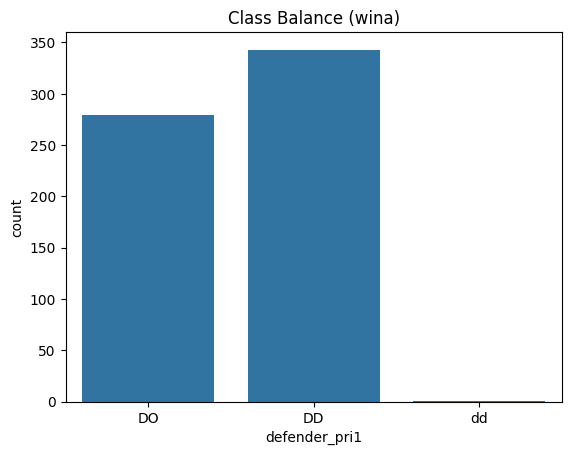

defender_pri1
DD    343
DO    279
dd      1
Name: count, dtype: int64


In [7]:
# Class balance
sns.countplot(x='defender_pri1', data=df)
plt.title('Class Balance (wina)')
plt.show()
print(df['defender_pri1'].value_counts())

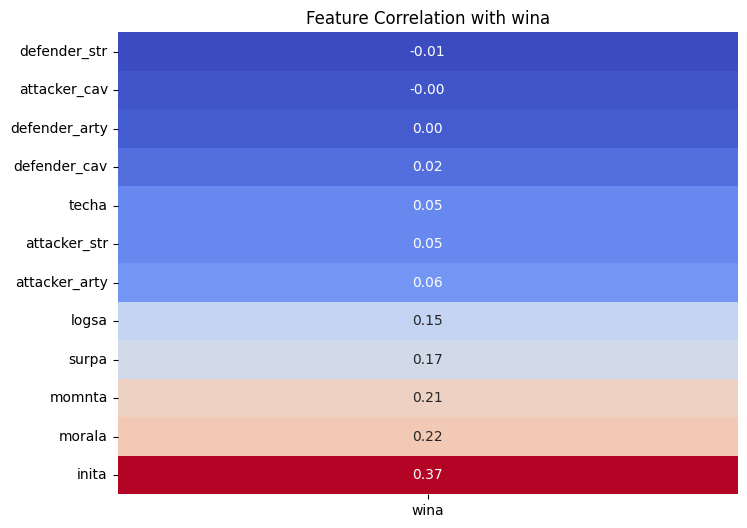

In [9]:
# Correlation of numerical features with wina
num_cols_eda = ['surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita',
                'attacker_str', 'attacker_cav', 'attacker_arty',
                'defender_str', 'defender_cav', 'defender_arty', 'wina']

corr = df[num_cols_eda].corr()['wina'].drop('wina').sort_values()

plt.figure(figsize=(8, 6))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Feature Correlation with wina')
plt.show()

## 4. Preprocessing Pipeline

In [10]:
# Separate features from targets (drop all targets from X)
target_cols = ['wina', 'attacker_cas', 'defender_cas', 'attacker_carty', 'defender_carty']
X = df.drop(columns=target_cols)
y = df['wina']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Continuous numerical features (army sizes — scaled)
num_feat = ['attacker_str', 'attacker_cav', 'attacker_arty',
            'defender_str', 'defender_cav', 'defender_arty']

# Ordinal/low-cardinality features (already 0-imputed above; one-hot encoded)
low_card_feat = ['surpa', 'morala', 'logsa', 'momnta', 'techa', 'inita',
                 'post1', 'terra1', 'terra2', 'attacker_pri1', 'defender_pri1']

# Commander quality — already in [0, 1], passed through unchanged
quality_feat = ['att_comm_quality', 'def_comm_quality']

# Pipelines
num_transf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy='median'))
])

low_card_transf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',      num_transf,      num_feat),
        ('low_card', low_card_transf, low_card_feat),
        ('quality',  'passthrough',   quality_feat),
    ],
    remainder='drop'
)

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# fit_transform on train, transform only on test
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed  = full_pipeline.transform(X_test)

print(f'Processed train shape: {X_train_processed.shape}')

Processed train shape: (528, 49)


## 5. Model Training with Bayesian Hyperparameter Search

In [12]:
models = {
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss'),
}

param_spaces = {
    'Random Forest': {
        'n_estimators': (10, 300),
        'max_depth': (3, 13),
        'min_samples_split': (2, 10),
        'min_samples_leaf': (4, 10),
        'class_weight': ['balanced'],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False],
        'criterion': ['gini', 'entropy']
    },
    'XGBoost': {
        'n_estimators': (50, 1500),
        'learning_rate': (0.001, 0.5, 'log-uniform'),
        'max_depth': (5, 15),
        'min_child_weight': (1, 5),
        'subsample': (0.5, 0.9),
        'colsample_bytree': (0.5, 0.9),
        'gamma': (0, 5),
        'scale_pos_weight': (1, 10)
    }
}

In [13]:
f1_scorer = make_scorer(f1_score, average='weighted')
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

best_models = {}
best_params  = {}

for name, model in tqdm(models.items(), desc='Optimising models', unit='model'):
    opt = BayesSearchCV(
        model,
        param_spaces[name],
        n_iter=50,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=f1_scorer,
        n_jobs=1,
        random_state=42
    )
    opt.fit(X_train_processed, y_train)
    best_models[name] = opt.best_estimator_
    best_params[name]  = opt.best_params_

Optimising models: 100%|██████████| 2/2 [06:09<00:00, 184.85s/model]


## 6. Evaluation

In [14]:
results = []
for name, model in tqdm(best_models.items(), desc='Evaluating models'):
    y_train_pred = model.predict(X_train_processed)
    y_test_pred  = model.predict(X_test_processed)

    f1_train = f1_score(y_train, y_train_pred, average='weighted')
    f1_test  = f1_score(y_test,  y_test_pred,  average='weighted')
    f1_cv    = cross_val_score(model, X_train_processed, y_train, cv=skf, scoring=f1_scorer).mean()

    params_str = ', '.join(f'{k}: {v}' for k, v in best_params[name].items())
    results.append([name, f1_train, f1_test, f1_cv, params_str])

results_df = pd.DataFrame(results, columns=[
    'Model', 'F1 Train', 'F1 Test', 'F1 CV', 'Best Params'
])
pd.set_option('display.max_colwidth', None)
results_df

Evaluating models: 100%|██████████| 2/2 [00:02<00:00,  1.39s/it]


,Model,F1 Train,F1 Test,F1 CV,Best Params
0,Random Forest,0.950912,0.871490,0.909298,"bootstrap: True, class_weight: balanced, criterion: gini, max_depth: 13, max_features: sqrt, min_samples_leaf: 4, min_samples_split: 7, n_estimators: 300"
1,XGBoost,0.959965,0.908659,0.914274,"colsample_bytree: 0.6879229739951038, gamma: 1, learning_rate: 0.04680017632064504, max_depth: 15, min_child_weight: 4, n_estimators: 1500, scale_pos_weight: 1, subsample: 0.8045292812130309"


## 7. Voting Classifier (Ensemble)

In [15]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf',     best_models['Random Forest']),
        ('xgb',    best_models['XGBoost']),
    ],
    voting='soft',
    weights=[1, 2]
)

voting_clf.fit(X_train_processed, y_train)

y_pred = voting_clf.predict(X_test_processed)
print(f'Voting Classifier F1 (test): {f1_score(y_test, y_pred, average="weighted"):.4f}')

Voting Classifier F1 (test): 0.9013


## 8. Threshold Optimisation & Final Analysis

In [16]:
y_probs = voting_clf.predict_proba(X_test_processed)[:, 1]

# Find threshold that maximises weighted F1
best_threshold, best_f1 = 0.5, 0
for t in np.linspace(0, 1, 1000):
    y_pred_t = (y_probs > t).astype(int)
    f1 = f1_score(y_test, y_pred_t, average='weighted')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best F1 (weighted): {best_f1:.4f}')

y_pred_final = (y_probs > best_threshold).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final))

Best threshold: 0.3874
Best F1 (weighted): 0.9087

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        48
           1       0.92      0.94      0.93        84

    accuracy                           0.91       132
   macro avg       0.90      0.90      0.90       132
weighted avg       0.91      0.91      0.91       132



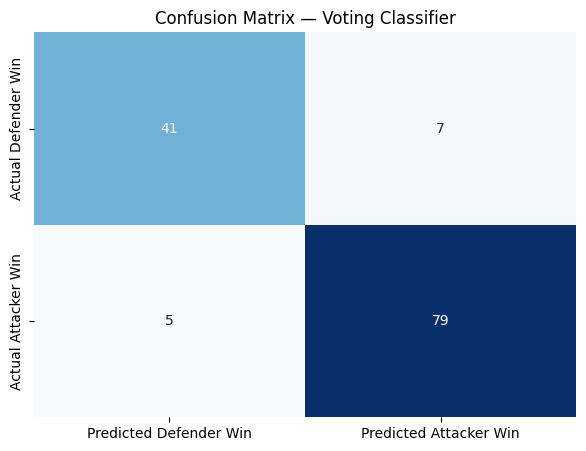

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Defender Win', 'Predicted Attacker Win'],
            yticklabels=['Actual Defender Win', 'Actual Attacker Win'])
plt.title('Confusion Matrix — Voting Classifier')
plt.show()

In [19]:
# Bundle pipeline, model and threshold together
model_bundle = {
    'pipeline':  full_pipeline,
    'model':     voting_clf,
    'threshold': best_threshold
}

joblib.dump(model_bundle, 'battle_outcome_wina.pkl')
print('Model saved.')

Model saved.
